# Brownian Motion & Random Lattice Walks


## Modeling Uncertainty

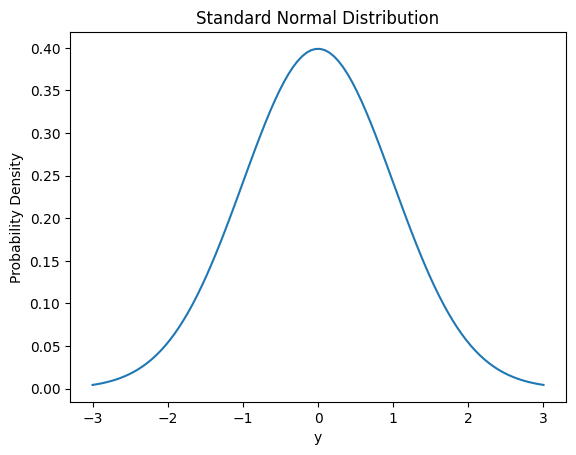

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the range of x values
x = np.linspace(-3, 3, 100)

# Calculate the probability density function (PDF) for the standard normal distribution
y = norm.pdf(x, loc=0, scale=1)

# Plot the PDF
plt.plot(x, y)

# Add labels and title
plt.xlabel('y')
plt.ylabel('Probability Density')
plt.title('Standard Normal Distribution')

# Display the plot
plt.show()


In [ ]:
import numpy as np

t = 0 # the initial time value of our process
dt = 0.5 # how big our time step is
T = 30 # the final time value of our process

X_initial = 15 # the inital value of our random process
X = X_initial # the current value of our random process
alpha = 0.5 # drift term (deterministic/ non-random)
volatility = 1 # a measure of how much noise there is
X_t = [X] # Storage of our X(t) values over time.

# One simulation Example
while t < T:
  t = t + dt
  dX = alpha * dt + volatility * np.random.normal(0, 1)
  X = X + dX
  X_t.append(X)
  print('t = ', t, ', X = ', X, ', dX = ', dX)

t =  0.5 , X =  14.114371761599017 , dX =  -0.8856282384009837
t =  1.0 , X =  14.378317593475018 , dX =  0.26394583187599974
t =  1.5 , X =  14.265085468510257 , dX =  -0.11323212496475976
t =  2.0 , X =  11.910609579222943 , dX =  -2.354475889287315
t =  2.5 , X =  11.629410022091582 , dX =  -0.2811995571313608
t =  3.0 , X =  12.41772496877658 , dX =  0.7883149466849978
t =  3.5 , X =  12.716151990678865 , dX =  0.2984270219022845
t =  4.0 , X =  13.412277477269395 , dX =  0.6961254865905309
t =  4.5 , X =  13.83506848515169 , dX =  0.42279100788229385
t =  5.0 , X =  14.793625149357 , dX =  0.958556664205311
t =  5.5 , X =  16.894210175278207 , dX =  2.100585025921207
t =  6.0 , X =  16.722472433670504 , dX =  -0.171737741607704
t =  6.5 , X =  16.719437368636545 , dX =  -0.003035065033959783
t =  7.0 , X =  16.98281449238318 , dX =  0.26337712374663474
t =  7.5 , X =  17.14088017485515 , dX =  0.15806568247196864
t =  8.0 , X =  19.30847985367987 , dX =  2.167599678824722
t =  8.5

After many simulations we start to see a pattern in our results.

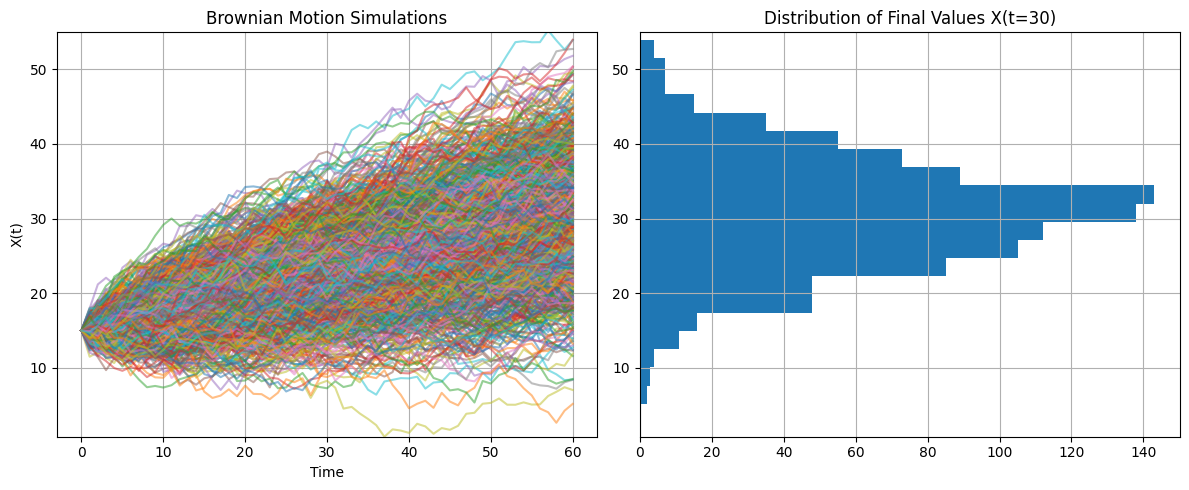

In [ ]:
import matplotlib.pyplot as plt

n_sim = 1000 # Number of simulations
X_t_sim_result = [] # Storage of our X(t) lists over time.

for i in range(n_sim):
  while t < T:
    t = t + dt
    dX = alpha * dt + volatility * np.random.normal(0, 1)
    X = X + dX
    X_t.append(X)
  X_t_sim_result.append(X_t)
  X = X_initial
  X_t = [X]
  t = 0

def min_of_list_of_lists(list_of_lists):
  """Calculates the minimum value in a list of lists.

  Args:
    list_of_lists: A list of lists containing numerical values.

  Returns:
    The minimum value found in the list of lists.
  """
  min_value = float('inf')
  for sublist in list_of_lists:
    min_value_sublist = min(sublist)
    if min_value_sublist < min_value:
      min_value = min_value_sublist
  return min_value


# Create the figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot the lines
for i in range(n_sim):
  axs[0].plot(X_t_sim_result[i], alpha=0.5)

# Set titles and labels
axs[0].set_title('Brownian Motion Simulations')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('X(t)')

# Plot the histogram
final_values = [X_t_sim_result[i][-1] for i in range(n_sim)]
axs[1].hist(final_values, bins=20, orientation='horizontal')
axs[1].set_title(f'Distribution of Final Values X(t={T})')
max_value = max(final_values)
min_value = min_of_list_of_lists(X_t_sim_result)
axs[0].set_ylim(min_value, max_value + 1)
axs[1].set_ylim(min_value, max_value + 1)

axs[0].grid(True)
axs[1].grid(True)
# Adjust layout and display the plot
plt.tight_layout()
plt.show()
